<h1>Chapter 8-Homework-Problem 1</h1>

<p>In this exercise, we will use a simple neuronal network to analyze customer behavior and predict whether a customer will leave a company, called churn. We use a real-world dataset from IBM that is widely used in business analytics and machine learning. We used a logistic regression to estimate this problem in Chapter 7.</p>

<p>A telecommunications company wants to understand why customers cancel their service. Each observation represents one customer.</p>

<p>The dependent variable is the churn and defined below:</p>

<p>•	1 = Customer leaves<br />
•	0 = Customer stays</p>

<p>These explanatory variables help explain why customers leave and are defined below:

<p>•	tenure – number of months the customer has stayed<br />
•	MonthlyCharges – monthly bill amount<br />
•	TotalCharges – total amount paid<br />
•	Contract – type of contract (month-to-month, one year, two year)<br />
•	InternetService – type of internet service<br />
•	PaymentMethod – how the customer pays<br />
•	SeniorCitizen – whether the customer is elderly</p>

<p>Please train a neuronal network to predict churn. The dataset is Chapter_07-churn_data.csv</p>


Epoch 1/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7222 - loss: 0.5577 - val_accuracy: 0.7218 - val_loss: 0.5065
Epoch 2/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7373 - loss: 0.4906 - val_accuracy: 0.7218 - val_loss: 0.4834
Epoch 3/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7378 - loss: 0.4775 - val_accuracy: 0.7404 - val_loss: 0.4743
Epoch 4/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7604 - loss: 0.4712 - val_accuracy: 0.7609 - val_loss: 0.4690
Epoch 5/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7813 - loss: 0.4665 - val_accuracy: 0.7858 - val_loss: 0.4636
Epoch 6/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7869 - loss: 0.4621 - val_accuracy: 0.7920 - val_loss: 0.4585
Epoch 7/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7876 - loss: 0.4582 - val_accuracy: 0.7982 - val_loss: 0.4552
Epoch 8/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7893 - loss: 0.4559 - val_accu

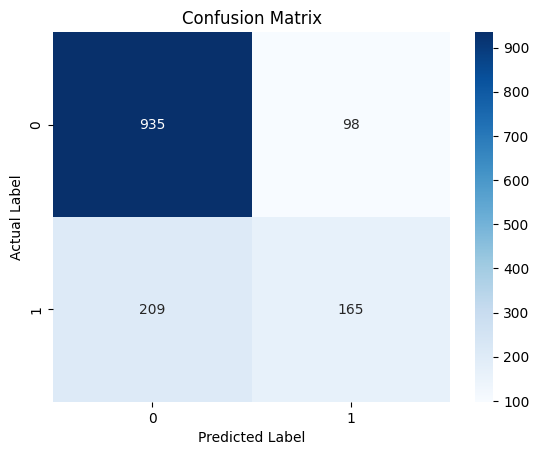



Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.91      0.86      1033
           1       0.63      0.44      0.52       374

    accuracy                           0.78      1407
   macro avg       0.72      0.67      0.69      1407
weighted avg       0.77      0.78      0.77      1407



In [1]:
# ================================
# 1. Import libraries
# ================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# ================================
# 2. Load dataset
# ================================
df = pd.read_csv("Chapter_07-churn_data.csv")

# ================================
# 3. Drop missing values (as requested)
# ================================

# Convert to numeric → blanks become NaN
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Drop missing values
df = df.dropna()

# ================================
# 4. Encode target variable
# ================================
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

# ================================
# 5. Encode categorical variables
# ================================
categorical_cols = [
    "Contract",
    "InternetService",
    "PaymentMethod"
]

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# ================================
# 6. Features and target
# ================================

X = df[['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']]
y = df['Churn']

# ================================
# 7. Train-test split
# ================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ================================
# 8. Scale features
# ================================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ================================
# 9. Build neural network
# ================================

model = keras.Sequential([
    keras.Input(shape=(X_train.shape[1],)),  # explicit input layer
    layers.Dense(16, activation='relu'),
    layers.Dense(8, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

# ================================
# 10. Compile model
# ================================
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# ================================
# 11. Early stopping callback
# ================================
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',     # watch validation loss
    patience=5,             # stop after 5 epochs of no improvement
    restore_best_weights=True
)

# ================================
# 12. Train model
# ================================
history = model.fit(
    X_train, y_train,
    epochs=100,                  # set high, early stopping will control it
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

# ================================
# 13. Evaluate model
# ================================
loss, accuracy = model.evaluate(X_test, y_test)
print(f"\nTest Accuracy: {accuracy:.4f}")

# ================================
# 14. Predictions
# ================================
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

# --------------------------------------------
# 15. Visualize confusion matrix
# --------------------------------------------
plt.figure()
sns.heatmap(
    pd.DataFrame(confusion_matrix(y_test, y_pred)),
    annot=True,
    fmt='g',
    cmap='Blues'
)

plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

print()
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
